# 문항 1 헬스케어 보험료 예측 회귀모델 구현

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import cross_val_score

import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('insurance.csv')
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 94.5 KB


In [4]:
df.isnull().sum()
# 결측치 없음

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [5]:
X = df.drop(columns="charges")
y = df["charges"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [6]:
num_features = ["age", "bmi", "children"]
cat_features = ["sex", "smoker", "region"]

ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_features),
        ("cat", ohe, cat_features),
    ]
)

# 변환 결과 미리보기
sample = preprocessor.fit_transform(X_train)
feat_names = preprocessor.get_feature_names_out()

pd.DataFrame(sample, columns=feat_names).head()

,num__age,num__bmi,num__children,cat__sex_female,cat__sex_male,cat__smoker_no,cat__smoker_yes,cat__region_northeast,cat__region_northwest,cat__region_southeast,cat__region_southwest
0,0.472227,-1.756525,0.734336,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
1,0.543313,-1.033082,-0.911192,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
2,0.898745,-0.943687,-0.911192,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
3,-0.025379,0.622393,3.202629,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
4,1.040918,-1.504893,1.557100,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0


In [9]:
kfold = KFold(n_splits=5, shuffle=True, random_state=42)
def cv_report(model, name, X=X_train, y=y_train):
    rmse = -cross_val_score(model, X, y, cv=kfold, scoring="neg_root_mean_squared_error")
    r2   =  cross_val_score(model, X, y, cv=kfold, scoring="r2")
    print(f"{name:<22} RMSE {rmse.mean():>9,.0f} (±{rmse.std():,.0f})   R2 {r2.mean():.4f}")
    return {"model": name, "CV_RMSE": rmse.mean(), "CV_RMSE_std": rmse.std(), "CV_R2": r2.mean()}

results = []
results.append(cv_report(Pipeline([("prep", preprocessor), ("model", DummyRegressor(strategy="mean"))]), "Dummy (mean)"))
results.append(cv_report(Pipeline([("prep", preprocessor), ("model", LinearRegression())]), "LinearRegression"))
results.append(cv_report(Pipeline([("prep", preprocessor), ("model", Ridge(alpha=1.0))]), "Ridge"))
results.append(cv_report(Pipeline([("prep", preprocessor), ("model", Lasso(alpha=1.0))]), "Lasso"))
results.append(cv_report(Pipeline([("prep", preprocessor), ("model", DecisionTreeRegressor(random_state=42))]), "Decision Tree"))
results.append(cv_report(Pipeline([("prep", preprocessor), ("model", RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))]), "Random Forest"))
results.append(cv_report(Pipeline([("prep", preprocessor), ("model", GradientBoostingRegressor(n_estimators=100, random_state=42))]), "Gradient Boosting"))


Dummy (mean)           RMSE    12,017 (±362)   R2 -0.0042
LinearRegression       RMSE     6,123 (±492)   R2 0.7389
Ridge                  RMSE     6,123 (±492)   R2 0.7389
Lasso                  RMSE     6,123 (±492)   R2 0.7389
Decision Tree          RMSE     6,366 (±580)   R2 0.7175
Random Forest          RMSE     4,895 (±472)   R2 0.8332
Gradient Boosting      RMSE     4,645 (±575)   R2 0.8493


In [10]:
res = pd.DataFrame(results)
res.sort_values(by="CV_RMSE", inplace=True)
res

,model,CV_RMSE,CV_RMSE_std,CV_R2
6,Gradient Boosting,4645.119378,574.881632,0.849313
5,Random Forest,4894.865897,471.836609,0.833223
3,Lasso,6123.253505,491.523247,0.738862
2,Ridge,6123.344389,491.815424,0.738855
1,LinearRegression,6123.353823,491.646746,0.738853
4,Decision Tree,6365.646471,579.619230,0.717454
0,Dummy (mean),12017.188802,361.868270,-0.004244


In [11]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV

gb_pipe = Pipeline([("prep", preprocessor), ("model", GradientBoostingRegressor(random_state=42))])

gb_grid = {
    "model__n_estimators":  [100, 300, 500],
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__max_depth":     [2, 3, 4],
    "model__subsample":     [0.8, 1.0],
}

gb_search = GridSearchCV(
    gb_pipe, gb_grid, cv=kfold,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1, verbose=0
)
gb_search.fit(X_train, y_train)
best_gb_model = gb_search.best_estimator_
best_gb_params = gb_search.best_params_
best_gb_score = gb_search.best_score_

In [12]:
from sklearn.metrics import mean_absolute_error, mean_absolute_error, mean_squared_error, r2_score


def evaluate(model, X_tr, y_tr, X_te, y_te, name="model"):
    model.fit(X_tr, y_tr)
    pred_tr, pred_te = model.predict(X_tr), model.predict(X_te)
    out = {
        "model": name,
        "Train RMSE": np.sqrt(mean_squared_error(y_tr, pred_tr)),
        "Test RMSE":  np.sqrt(mean_squared_error(y_te, pred_te)),
        "Test MAE":   mean_absolute_error(y_te, pred_te),
        "Train R2":   r2_score(y_tr, pred_tr),
        "Test R2":    r2_score(y_te, pred_te),
    }
    return out, pred_te

final_rows = []

lin_pipe = Pipeline([("prep", preprocessor), ("model", LinearRegression())])

row_lin, pred_lin = evaluate(lin_pipe, X_train, y_train, X_test, y_test, "LinearRegression (baseline)")
row_best, pred_best = evaluate(best_gb_model, X_train, y_train, X_test, y_test, "Tuned best model")

final_rows += [row_lin, row_best]

final_df = pd.DataFrame(final_rows)
display(final_df.style.format({
    "Train RMSE": "{:,.0f}", "Test RMSE": "{:,.0f}", "Test MAE": "{:,.0f}",
    "Train R2": "{:.4f}", "Test R2": "{:.4f}"}))

,model,Train RMSE,Test RMSE,Test MAE,Train R2,Test R2
0,LinearRegression (baseline),"6,106","5,796","4,181",0.7417,0.7836
1,Tuned best model,"4,179","4,342","2,442",0.8790,0.8785


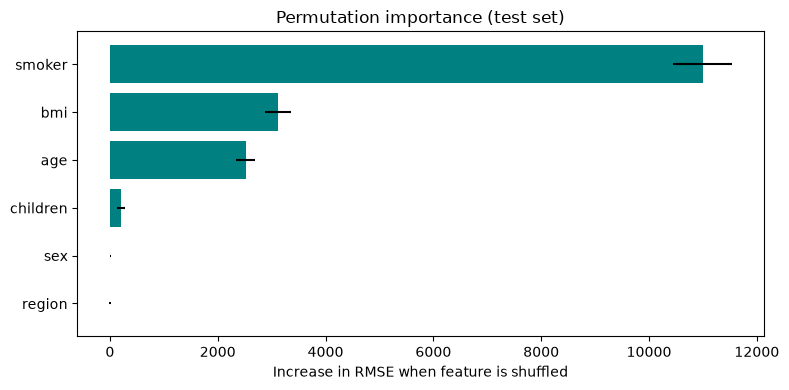

,feature,importance,std
0,smoker,10995.615472,551.974895
1,bmi,3123.571637,237.606791
2,age,2518.351028,173.857829
3,children,211.104747,76.100849
4,sex,2.245397,9.138953
5,region,1.674829,25.829383


In [13]:
from sklearn.inspection import permutation_importance


perm = permutation_importance(
    best_gb_model, X_test, y_test,
    n_repeats=30, random_state=42, scoring="neg_root_mean_squared_error"
)
imp = pd.DataFrame({
    "feature": X_test.columns,
    "importance": perm.importances_mean,
    "std": perm.importances_std,
}).sort_values("importance", ascending=False)

plt.figure(figsize=(8, 4))
plt.barh(imp["feature"], imp["importance"], xerr=imp["std"], color="teal")
plt.gca().invert_yaxis()
plt.xlabel("Increase in RMSE when feature is shuffled")
plt.title("Permutation importance (test set)")
plt.tight_layout(); plt.show()
display(imp.reset_index(drop=True))

# 문항 2 전설 포켓몬 분류모델 구현

In [14]:
df = pd.read_csv('pokemon.csv')
df.head()

,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,525,80,82,83,100,100,80,1,False
3,3,VenusaurMega Venusaur,Grass,Poison,625,80,100,123,122,120,80,1,False
4,4,Charmander,Fire,NaN,309,39,52,43,60,50,65,1,False


In [15]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   #           800 non-null    int64
 1   Name        800 non-null    str  
 2   Type 1      800 non-null    str  
 3   Type 2      414 non-null    str  
 4   Total       800 non-null    int64
 5   HP          800 non-null    int64
 6   Attack      800 non-null    int64
 7   Defense     800 non-null    int64
 8   Sp. Atk     800 non-null    int64
 9   Sp. Def     800 non-null    int64
 10  Speed       800 non-null    int64
 11  Generation  800 non-null    int64
 12  Legendary   800 non-null    bool 
dtypes: bool(1), int64(9), str(3)
memory usage: 89.3 KB


In [16]:
df.isnull().sum()
# 포켓몬의 특성상 두번째 타입이 있을수도, 없을수도 있기때문에 결측치가 존재해도 무방함
# 하지만 모델에 사용하기에 조금 애매하기 때문에 타입수를 기준으로 새로운 column 생성
df['type_count'] = df[['Type 1', 'Type 2']].notnull().sum(axis=1)
df.head()

,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary,type_count
0,1,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,False,2
1,2,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,1,False,2
2,3,Venusaur,Grass,Poison,525,80,82,83,100,100,80,1,False,2
3,3,VenusaurMega Venusaur,Grass,Poison,625,80,100,123,122,120,80,1,False,2
4,4,Charmander,Fire,NaN,309,39,52,43,60,50,65,1,False,1


In [17]:
df_clean = df.copy()[['Total', 'HP', 'Attack', 'Defense', 'Sp. Atk', 'Sp. Def', 'Speed', 'Generation', 'Legendary', 'type_count']]
df_clean.head()

,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary,type_count
0,318,45,49,49,65,65,45,1,False,2
1,405,60,62,63,80,80,60,1,False,2
2,525,80,82,83,100,100,80,1,False,2
3,625,80,100,123,122,120,80,1,False,2
4,309,39,52,43,60,50,65,1,False,1


In [24]:
X = df_clean.drop(columns=['Legendary'])
y = df_clean['Legendary'].astype(int)

num_features = [
    "Total", "HP", "Attack", "Defense",
    "Sp. Atk", "Sp. Def", "Speed", "type_count"
]
cat_features = ["Generation"]

X_train_full, X_val, y_train_full, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

X_train, X_test, y_train, y_test = train_test_split(X_train_full, y_train_full, test_size=0.25, random_state=42, stratify=y_train_full)

def fill_type2(data):
    d = data.copy()
    d["Generation"] = d["Generation"].astype(str)
    return d

X_train, X_test, X_val = map(fill_type2, [X_train, X_test, X_val])
X_train_full = fill_type2(X_train_full)

ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_features),
    ("cat", ohe, cat_features),
])

In [25]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, f1_score

dummy = DummyClassifier(strategy="most_frequent").fit(X_train, y_train)
dummy_pred = dummy.predict(X_test)
dummy_acc = accuracy_score(y_test, dummy_pred)
dummy_f1 = f1_score(y_test, dummy_pred)
print("Dummy Classifier Accuracy:", dummy_acc)
print("Dummy Classifier F1 Score:", dummy_f1)

Dummy Classifier Accuracy: 0.91875
Dummy Classifier F1 Score: 0.0


In [26]:
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def cv_report(model, name):
    f1  = cross_val_score(model, X_train, y_train, cv=skf, scoring="f1")
    auc = cross_val_score(model, X_train, y_train, cv=skf, scoring="roc_auc")
    ap  = cross_val_score(model, X_train, y_train, cv=skf, scoring="average_precision")
    print(f"{name:<34} F1 {f1.mean():.3f} (±{f1.std():.3f})   ROC-AUC {auc.mean():.3f}   PR-AUC {ap.mean():.3f}")
    return {"model": name, "CV_F1": f1.mean(), "CV_F1_std": f1.std(),
            "CV_ROC_AUC": auc.mean(), "CV_PR_AUC": ap.mean()}

results = []

results.append(cv_report(Pipeline([("dummy", DummyClassifier(strategy="most_frequent"))]), "Dummy Classifier"))
results.append(cv_report(Pipeline([("LogisticRegression", LogisticRegression(max_iter=1000, random_state=42))]), "Logistic Regression"))
results.append(cv_report(Pipeline([("DecisionTree", DecisionTreeClassifier(random_state=42))]), "Decision Tree"))
results.append(cv_report(Pipeline([("RandomForest", RandomForestClassifier(n_estimators=100, random_state=42))]), "Random Forest"))
results.append(cv_report(Pipeline([("GradientBoosting", GradientBoostingClassifier(n_estimators=100, random_state=42))]), "Gradient Boosting"))

res = pd.DataFrame(results)
res.sort_values(by="CV_F1", ascending=False)

Dummy Classifier                   F1 0.000 (±0.000)   ROC-AUC 0.500   PR-AUC 0.081
Logistic Regression                F1 0.640 (±0.215)   ROC-AUC 0.972   PR-AUC 0.767
Decision Tree                      F1 0.599 (±0.141)   ROC-AUC 0.769   PR-AUC 0.419
Random Forest                      F1 0.733 (±0.145)   ROC-AUC 0.982   PR-AUC 0.820
Gradient Boosting                  F1 0.769 (±0.119)   ROC-AUC 0.982   PR-AUC 0.792


,model,CV_F1,CV_F1_std,CV_ROC_AUC,CV_PR_AUC
4,Gradient Boosting,0.768599,0.118999,0.982486,0.791934
3,Random Forest,0.733403,0.144965,0.981955,0.820382
1,Logistic Regression,0.640171,0.215351,0.971875,0.767213
2,Decision Tree,0.598992,0.141185,0.768519,0.418909
0,Dummy Classifier,0.000000,0.000000,0.500000,0.081250


In [27]:
gb_pipe = Pipeline([("prep", preprocessor),
                    ("model", GradientBoostingClassifier(random_state=42))])

gb_grid = {
    "model__n_estimators":  [100, 300],
    "model__learning_rate": [0.05, 0.1],
    "model__max_depth":     [2, 3],
    "model__subsample":     [0.8, 1.0],
}
gb_search = GridSearchCV(gb_pipe, gb_grid, cv=skf, scoring="f1", n_jobs=-1)
gb_search.fit(X_train, y_train)
best_gb_model = gb_search.best_estimator_
y_pred_gb = best_gb_model.predict(X_test)
f1_gb = f1_score(y_test, y_pred_gb)

In [28]:
from sklearn.metrics import precision_score, accuracy_score, recall_score, f1_score, roc_auc_score, average_precision_score, classification_report


def evaluate(model, X_eval, y_eval, name="", threshold=0.5, show=True):
    proba = model.predict_proba(X_eval)[:, 1]
    pred = (proba >= threshold).astype(int)
    m = {
        "dataset": name,
        "Accuracy":  accuracy_score(y_eval, pred),
        "Precision": precision_score(y_eval, pred, zero_division=0),
        "Recall":    recall_score(y_eval, pred),
        "F1":        f1_score(y_eval, pred),
        "ROC-AUC":   roc_auc_score(y_eval, proba),
        "PR-AUC":    average_precision_score(y_eval, proba),
    }
    if show:
        print(f"===== {name} (threshold={threshold:.2f}) =====")
        print(classification_report(y_eval, pred, target_names=["Normal", "Legendary"], digits=3))
    return m, pred, proba

best_gb_model.fit(X_train, y_train)
test_metrics, test_pred, test_proba = evaluate(best_gb_model, X_test, y_test, "Test")

===== Test (threshold=0.50) =====
              precision    recall  f1-score   support

      Normal      0.954     0.993     0.973       147
   Legendary      0.857     0.462     0.600        13

    accuracy                          0.950       160
   macro avg      0.906     0.727     0.787       160
weighted avg      0.946     0.950     0.943       160



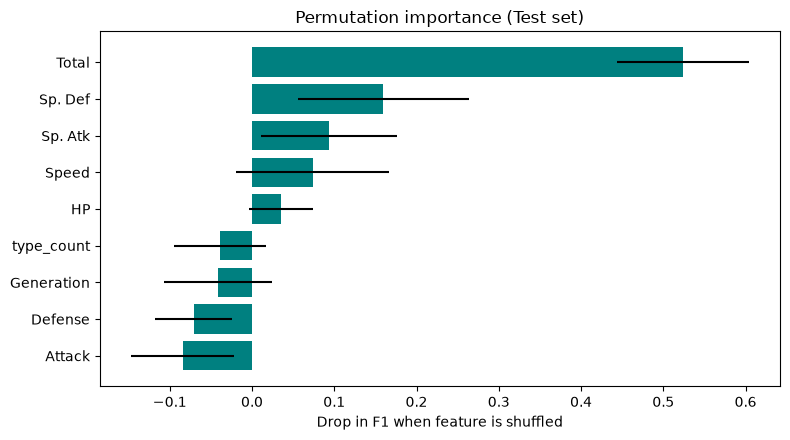

,feature,importance,std
0,Total,0.523755,0.080511
1,Sp. Def,0.159868,0.104272
2,Sp. Atk,0.094084,0.082683
3,Speed,0.073892,0.093047
4,HP,0.035464,0.039042
5,type_count,-0.038490,0.056099
6,Generation,-0.040877,0.065727
7,Defense,-0.070993,0.046688
8,Attack,-0.084418,0.063069


In [29]:
perm = permutation_importance(best_gb_model, X_test, y_test, n_repeats=30,
                              random_state=42, scoring="f1")
imp = pd.DataFrame({"feature": X_test.columns,
                    "importance": perm.importances_mean,
                    "std": perm.importances_std}).sort_values("importance", ascending=False)

plt.figure(figsize=(8, 4.5))
plt.barh(imp["feature"], imp["importance"], xerr=imp["std"], color="teal")
plt.gca().invert_yaxis(); plt.xlabel("Drop in F1 when feature is shuffled")
plt.title("Permutation importance (Test set)")
plt.tight_layout(); plt.show()
display(imp.reset_index(drop=True))

데이터를 학습, 테스트, 검증데이터로 분리하는 이유는 새로운 데이터셋을 모델에 적용했을 때에도 모델이 제대로 작동하게 하기 위해 입니다.

Train: 모델을 가르치기 위한 데이터

Test: 말그대로 테스트랄 하는 데이터셋. 테스트를하고 사용할 model과 hyper parameter를 정한다

Validation: 마지막 테스트로 사용하는 데이터셋